<a href="https://colab.research.google.com/github/ridaCR7/CarProject/blob/main/Copy_of_rop_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report

ZIP_PATH = "/content/proj rop.zip"
EXTRACT_PATH = "/content/proj rop"
DATA_DIR = os.path.join(EXTRACT_PATH, "proj rop")
BATCH_SIZE = 32
NUM_EPOCHS = 20
NUM_CLASSES = 4  # normal, stage1, stage2, stage3
IMAGE_SIZE = 224
LEARNING_RATE = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============== UNZIP FILE ================
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Files Extracted To:", EXTRACT_PATH)
print("Folders:", os.listdir(EXTRACT_PATH))

Files Extracted To: /content/proj rop
Folders: ['proj rop']


In [ ]:
DATA_DIR = os.path.join(EXTRACT_PATH, "proj rop")


In [ ]:
print("Subfolders in DATA_DIR:", os.listdir(DATA_DIR))


Subfolders in DATA_DIR: ['Stage1', 'stage 2', 'normal', 'stage 3']


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Where to store the split dataset
split_dir = "/content/dataset"
train_dir = os.path.join(split_dir, "train")
val_dir = os.path.join(split_dir, "val")
test_dir = os.path.join(split_dir, "test")

# Clear old split (optional)
for folder in [train_dir, val_dir, test_dir]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# Split each class folder
for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)
    images = os.listdir(class_path)

    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    for split_name, split_imgs in zip(["train", "val", "test"], [train_imgs, val_imgs, test_imgs]):
        split_class_dir = os.path.join(split_dir, split_name, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for img in split_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_dir, img)
            shutil.copyfile(src, dst)

print("✅ Dataset split into train, val, and test successfully!")


✅ Dataset split into train, val, and test successfully!


In [ ]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("📦 Data loaders ready.")


📦 Data loaders ready.


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 133MB/s]



Epoch 1/20
------------------------------
Train Accuracy: 0.4458
Val Accuracy: 0.5070
✅ Best model saved with accuracy: 0.5070 at epoch 1

Epoch 2/20
------------------------------
Train Accuracy: 0.7771
Val Accuracy: 0.5915
✅ Best model saved with accuracy: 0.5915 at epoch 2

Epoch 3/20
------------------------------
Train Accuracy: 0.9548
Val Accuracy: 0.6056
✅ Best model saved with accuracy: 0.6056 at epoch 3

Epoch 4/20
------------------------------
Train Accuracy: 0.9819
Val Accuracy: 0.6479
✅ Best model saved with accuracy: 0.6479 at epoch 4

Epoch 5/20
------------------------------
Train Accuracy: 0.9940
Val Accuracy: 0.6901
✅ Best model saved with accuracy: 0.6901 at epoch 5

Epoch 6/20
------------------------------
Train Accuracy: 0.9849
Val Accuracy: 0.6620

Epoch 7/20
------------------------------
Train Accuracy: 0.9880
Val Accuracy: 0.7042
✅ Best model saved with accuracy: 0.7042 at epoch 7

Epoch 8/20
------------------------------
Train Accuracy: 0.9940
Val Accuracy:

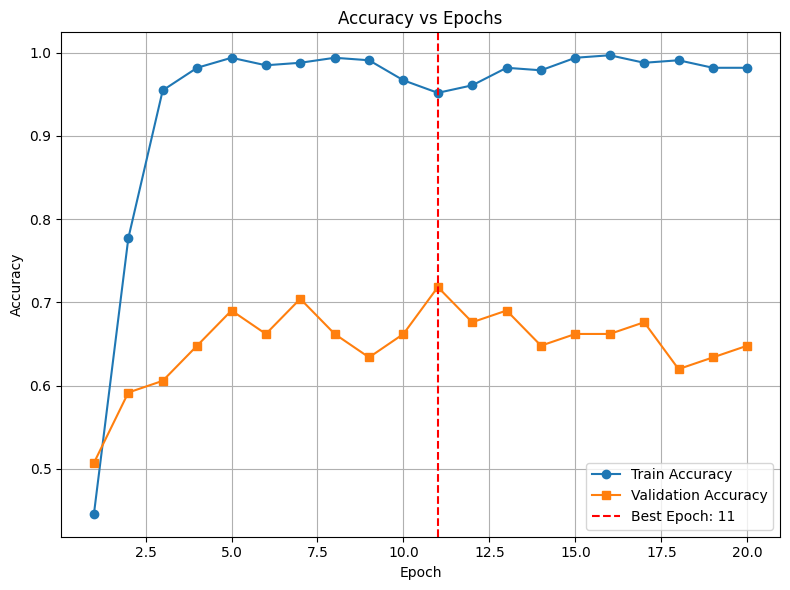

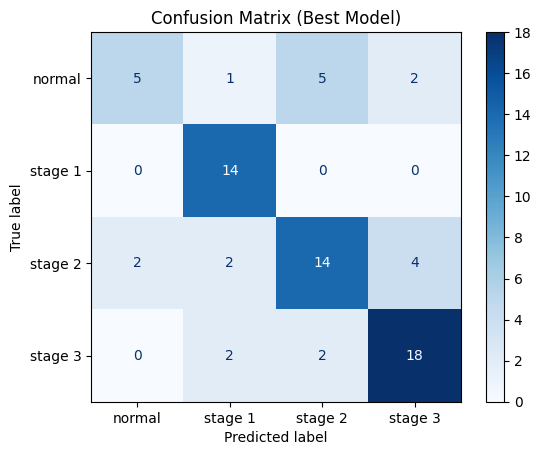


📊 Classification Report:
              precision    recall  f1-score   support

      normal     0.7143    0.3846    0.5000        13
     stage 1     0.7368    1.0000    0.8485        14
     stage 2     0.6667    0.6364    0.6512        22
     stage 3     0.7500    0.8182    0.7826        22

    accuracy                         0.7183        71
   macro avg     0.7169    0.7098    0.6956        71
weighted avg     0.7150    0.7183    0.7031        71

✅ Final Accuracy (on validation set): 0.7183


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, RandomSampler
from torchvision import models
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score)
import matplotlib.pyplot as plt

# === Setup ===
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 4
EPOCHS = 20
BATCH_SIZE = 32
CLASS_LABELS = ['normal', 'stage 1', 'stage 2', 'stage 3']

# === Loaders === (Assume train_dataset and val_dataset are already defined)
train_sampler = RandomSampler(train_dataset)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# === Model ===
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, NUM_CLASSES)
)
model.to(DEVICE)

# === Loss & Optimizer ===
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# === Training Loop ===
best_acc = 0.0
best_epoch = -1
train_acc_list, val_acc_list = [], []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    # === Training ===
    model.train()
    correct, total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total
    train_acc_list.append(train_accuracy)

    # === Validation ===
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_accuracy = correct / total
    val_acc_list.append(val_accuracy)

    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Accuracy: {val_accuracy:.4f}")

    if val_accuracy > best_acc:
        best_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pth")
        print(f"✅ Best model saved with accuracy: {best_acc:.4f} at epoch {best_epoch}")

# === Final Result ===
print("\n🏁 Training complete.")
print(f"🎯 Best Validation Accuracy: {best_acc:.4f} at Epoch {best_epoch}")

# === Accuracy Graph ===
plt.figure(figsize=(8, 6))
plt.plot(range(1, EPOCHS + 1), train_acc_list, label='Train Accuracy', marker='o')
plt.plot(range(1, EPOCHS + 1), val_acc_list, label='Validation Accuracy', marker='s')
plt.axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Confusion Matrix for Best Model ===
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        preds = torch.argmax(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Best Model)")
plt.show()

# === Classification Report ===
print("\n📊 Classification Report:")
report = classification_report(all_labels, all_preds, target_names=CLASS_LABELS, digits=4)
print(report)

# === Final Accuracy ===
final_accuracy = accuracy_score(all_labels, all_preds)
print(f"✅ Final Accuracy (on validation set): {final_accuracy:.4f}")


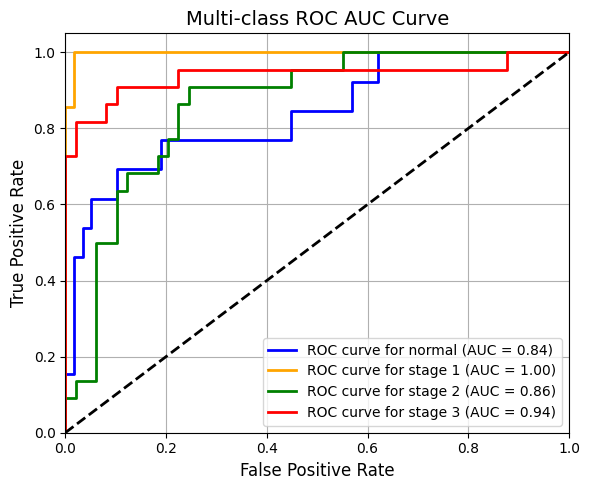

In [ ]:
import torch

# Define device based on availability of CUDA (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Now you can move your inputs and model to the defined device
model = model.to(device)


from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Ensure your model is in evaluation mode
model.load_state_dict(torch.load("best_model.pth", map_location=device))

model.eval()

# Collect all true labels and predictions
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in val_loader:  # or test_loader
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Binarize the labels for multi-class ROC
n_classes = 4
class_names = ['normal', 'stage 1', 'stage 2', 'stage 3']
y_test_binarized = label_binarize(all_labels, classes=[0, 1, 2, 3])

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])




# Plot ROC curve for each class
plt.figure(figsize=(6, 5))


colors = ['blue', 'orange', 'green', 'red']
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC curve for {class_names[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-class ROC AUC Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, RandomSampler
from torchvision import models, transforms
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

from torchvision.datasets import ImageFolder

# === Data Augmentation ===
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Dataset ===
train_dataset = ImageFolder(root='/content/dataset/train', transform=train_transforms)
val_dataset = ImageFolder(root='/content/dataset/val', transform=val_transforms)

# === Setup ===
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 4
EPOCHS = 20
BATCH_SIZE = 32
CLASS_LABELS = ['normal', 'stage 1', 'stage 2', 'stage 3']

# === Data Loaders ===
train_sampler = RandomSampler(train_dataset)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# === Model ===
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)
model.to(DEVICE)

# === Loss, Optimizer, Scheduler ===
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# === Training Loop ===
best_acc = 0.0
best_epoch = -1
train_acc_list, val_acc_list = [], []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    # === Training ===
    model.train()
    correct, total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total
    train_acc_list.append(train_accuracy)

    # === Validation ===
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_accuracy = correct / total
    val_acc_list.append(val_accuracy)

    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Val Accuracy: {val_accuracy:.4f}")

    if val_accuracy > best_acc:
        best_acc = val_accuracy
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pth")
        print(f"✅ Best model saved with accuracy: {best_acc:.4f} at epoch {best_epoch}")

    scheduler.step()

# === Final Result ===
print("\n🏁 Training complete.")
print(f"🎯 Best Validation Accuracy: {best_acc:.4f} at Epoch {best_epoch}")

# === Accuracy Graph ===
plt.figure(figsize=(8, 6))
plt.plot(range(1, EPOCHS + 1), train_acc_list, label='Train Accuracy', marker='o')
plt.plot(range(1, EPOCHS + 1), val_acc_list, label='Validation Accuracy', marker='s')
plt.axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Confusion Matrix for Best Model ===
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        preds = torch.argmax(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Best Model)")
plt.show()

# === Classification Report ===
print("\n📊 Classification Report:")
report_dict = classification_report(all_labels, all_preds, target_names=CLASS_LABELS, output_dict=True, digits=4)
print(classification_report(all_labels, all_preds, target_names=CLASS_LABELS, digits=4))

# === Final Metrics ===
final_accuracy = accuracy_score(all_labels, all_preds)
precision_macro = precision_score(all_labels, all_preds, average='macro')
recall_macro = recall_score(all_labels, all_preds, average='macro')
f1_macro = f1_score(all_labels, all_preds, average='macro')

precision_weighted = precision_score(all_labels, all_preds, average='weighted')
recall_weighted = recall_score(all_labels, all_preds, average='weighted')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')

print("\n✅ Final Metrics Summary (on Validation Set):")
print(f"Accuracy          : {final_accuracy:.4f}")
print(f"Macro Precision   : {precision_macro:.4f}")
print(f"Macro Recall      : {recall_macro:.4f}")
print(f"Macro F1-score    : {f1_macro:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall   : {recall_weighted:.4f}")
print(f"Weighted F1-score : {f1_weighted:.4f}")

# === ROC Curve ===
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Binarize labels for ROC
y_test_binarized = label_binarize(all_labels, classes=[0, 1, 2, 3])
fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve
plt.figure(figsize=(6, 5))
colors = ['blue', 'orange', 'green', 'red']
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'{CLASS_LABELS[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-class ROC AUC Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 58.1MB/s]



Epoch 1/20
------------------------------
Train Accuracy: 0.3554
Val Accuracy: 0.3803
✅ Best model saved with accuracy: 0.3803 at epoch 1

Epoch 2/20
------------------------------
Train Accuracy: 0.5181
Val Accuracy: 0.4930
✅ Best model saved with accuracy: 0.4930 at epoch 2

Epoch 3/20
------------------------------
Train Accuracy: 0.5482
Val Accuracy: 0.5352
✅ Best model saved with accuracy: 0.5352 at epoch 3

Epoch 4/20
------------------------------
Train Accuracy: 0.5663
Val Accuracy: 0.4789

Epoch 5/20
------------------------------
Train Accuracy: 0.6446
Val Accuracy: 0.6338
✅ Best model saved with accuracy: 0.6338 at epoch 5

Epoch 6/20
------------------------------
Train Accuracy: 0.6687
Val Accuracy: 0.6901
✅ Best model saved with accuracy: 0.6901 at epoch 6

Epoch 7/20
------------------------------
Train Accuracy: 0.7018
Val Accuracy: 0.6338

Epoch 8/20
------------------------------
Train Accuracy: 0.7500
Val Accuracy: 0.7183
✅ Best model saved with accuracy: 0.7183 at 

KeyboardInterrupt: 

<ipython-input-7-95fa6fadc246>:65: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.11/dist-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(



Epoch 1/20
------------------------------


<ipython-input-7-95fa6fadc246>:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.11/dist-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
<ipython-input-7-95fa6fadc246>:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train Accuracy: 0.2956
Val Accuracy  : 0.5070
✅ Best model saved with accuracy: 0.5070 at epoch 1

Epoch 2/20
------------------------------
Train Accuracy: 0.3699
Val Accuracy  : 0.4225

Epoch 3/20
------------------------------
Train Accuracy: 0.4676
Val Accuracy  : 0.5352
✅ Best model saved with accuracy: 0.5352 at epoch 3

Epoch 4/20
------------------------------
Train Accuracy: 0.4889
Val Accuracy  : 0.6479
✅ Best model saved with accuracy: 0.6479 at epoch 4

Epoch 5/20
------------------------------
Train Accuracy: 0.4831
Val Accuracy  : 0.5915

Epoch 6/20
------------------------------
Train Accuracy: 0.4971
Val Accuracy  : 0.6620
✅ Best model saved with accuracy: 0.6620 at epoch 6

Epoch 7/20
------------------------------
Train Accuracy: 0.5519
Val Accuracy  : 0.6620

Epoch 8/20
------------------------------
Train Accuracy: 0.5380
Val Accuracy  : 0.7465
✅ Best model saved with accuracy: 0.7465 at epoch 8

Epoch 9/20
------------------------------
Train Accuracy: 0.6121
Val A

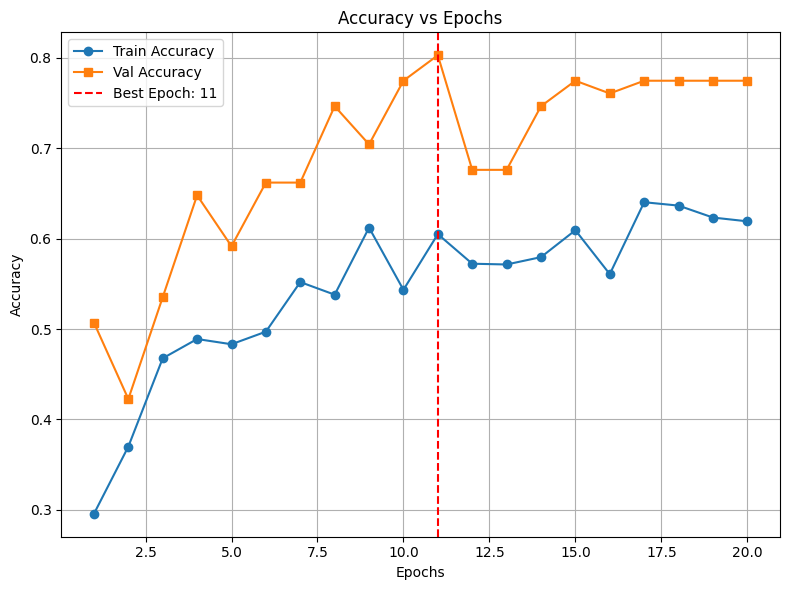

In [ ]:
import torch
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader, RandomSampler
from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import random

# === Setup ===
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 4
EPOCHS = 20
BATCH_SIZE = 32
CLASS_LABELS = ['normal', 'stage 1', 'stage 2', 'stage 3']
IMG_SIZE = 224

# === Transforms ===
train_transforms = transforms.Compose([
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Datasets and Loaders ===
train_dataset = ImageFolder('/content/dataset/train', transform=train_transforms)
val_dataset = ImageFolder('/content/dataset/val', transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=RandomSampler(train_dataset))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# === Model Definition ===
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)
model.to(DEVICE)

# === Loss, Optimizer, Scheduler ===
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = GradScaler()

# === MixUp Function ===
def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(DEVICE)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# === Training Loop ===
best_acc = 0.0
best_epoch = -1
train_acc_list, val_acc_list = [], []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    model.train()
    total_correct = 0
    total_samples = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        inputs, targets_a, targets_b, lam = mixup_data(inputs, labels)
        optimizer.zero_grad()

        with autocast():
            outputs = model(inputs)
            loss = mixup_criterion(outputs, targets_a, targets_b, lam)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = torch.argmax(outputs, dim=1)
        total_correct += (lam * preds.eq(targets_a).sum().item() + (1 - lam) * preds.eq(targets_b).sum().item())
        total_samples += labels.size(0)

    train_acc = total_correct / total_samples
    train_acc_list.append(train_acc)

    # === Validation ===
    model.eval()
    val_correct, val_total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            with autocast():
                outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = val_correct / val_total
    val_acc_list.append(val_acc)

    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy  : {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pth")
        print(f"✅ Best model saved with accuracy: {best_acc:.4f} at epoch {best_epoch}")

    scheduler.step()

# === Summary ===
print("\n🏁 Training complete.")
print(f"🎯 Best Validation Accuracy: {best_acc:.4f} at Epoch {best_epoch}")

# === Accuracy Plot ===
plt.figure(figsize=(8, 6))
plt.plot(range(1, EPOCHS + 1), train_acc_list, label='Train Accuracy', marker='o')
plt.plot(range(1, EPOCHS + 1), val_acc_list, label='Val Accuracy', marker='s')
plt.axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import torch
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

# === Labels and device ===
CLASS_LABELS = ['normal', 'stage 1', 'stage 2', 'stage 3']
STAGE_TO_INDEX = {label: i for i, label in enumerate(CLASS_LABELS)}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === Load the model ===
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = torch.nn.Sequential(
    torch.nn.Linear(model.fc.in_features, 512),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),
    torch.nn.Linear(512, len(CLASS_LABELS))
)
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()

# === Image transform ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# === Get image paths from user ===
num_images = int(input("📸 Enter number of ROP images to test: "))
image_paths = []
for i in range(num_images):
    path = input(f"Enter path for image {i+1}: ")
    image_paths.append(path)

# === Predict and display images side-by-side ===
predicted_stages = []

fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))  # Side-by-side layout

if num_images == 1:
    axes = [axes]  # Make sure it's iterable

for ax, path in zip(axes, image_paths):
    img = Image.open(path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)
        stage = CLASS_LABELS[predicted.item()]
        predicted_stages.append(stage)

    ax.imshow(img)
    ax.set_title(f"Predicted: {stage}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# === Analyze progression ===
indexes = [STAGE_TO_INDEX[stage] for stage in predicted_stages]

if all(x == indexes[0] for x in indexes):
    status = "🟡 Stable"
elif indexes == sorted(indexes, reverse=True):
    status = "🟢 Improving"
elif indexes == sorted(indexes):
    status = "🔴 Deteriorating"
else:
    status = "🟠 Mixed/Fluctuating"

# === Final Output ===
print("\nPredicted Stages:")
for i, stage in enumerate(predicted_stages, 1):
    print(f"Image {i}: {stage}")

print(f"\nCondition Trend: {status}")



📸 Enter number of ROP images to test: 100


KeyboardInterrupt: Interrupted by user